## STOCHASTIC MODELING
MODULE 6 | LESSON 3


---



# **RL for Asset Allocation: Portfolio Rotation**

|  |  |
|:---|:---|
|**Reading Time** |  70 minutes |
|**Prior Knowledge** | MDP, Policy iteration |
|**Keywords** | MDP, Portfolio rotation, Asset Allocation


---

Now that we are more versed on Reinforcement Learning (RL), it's time to tackle some real-world problems. In this lesson, we will leverage RL tools for portfolio allocation. We will use RL in a portfolio rotation strategy, trying to predict when investors should tilt their portfolios towards U.S. Equity (S&P500) or long-term bonds.  

In [ ]:
!pip install -r numpy pandas matplotlib

In [1]:
# Import libraries to be used later on
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Portfolio allocation strategies**

Let's first start by gathering data on the historical performance of the relevant assets. In this case we will consider the following highly-tradable assets:

- SPY: ETF on the S&P500 index. It essentially mimics the performance of the large cap Equity market in the U.S. This will be our Equity asset.

- IEF: ETF on the U.S. Treasury bonds in the 7 - 10 year maturity. This will be our Bond asset.

- SHY: ETF on the U.S. Treasury bonds in the 1 - 3 year maturity. We will consider this asset as our proxy for a "cash" investment in future potential enhancements of the algortihm.


Obtainting data on these 3 assets is extremely simple. However, for the sake of homogeneity we directly provide these data in the accompanying .csv file. Let's take a look at it:

In [3]:
df = pd.read_csv("taa_monthly_data.csv", parse_dates=["date"], index_col="date")
df.head()

,px_spy,px_ief,px_shy,ret_spy,ret_ief,ret_shy
date,,,,,,
2004-01-31,75.756371,47.605370,55.095871,NaN,NaN,NaN
2004-02-29,76.784378,48.372673,55.362484,0.013570,0.016118,0.004839
2004-03-31,75.767365,49.000061,55.518364,-0.013245,0.012970,0.002816
2004-04-30,74.333755,46.870399,54.928692,-0.018921,-0.043462,-0.010621
2004-05-31,75.606583,46.621506,54.926003,0.017123,-0.005310,-0.000049


The file contains data on monthly prices (px) and returns (ret) for each of these three assets in the period Jan-04 to Oct-25. The figure below plots the evolution of U.S. Equity (SPY) and Bonds (IEF) ETF prices in the period:

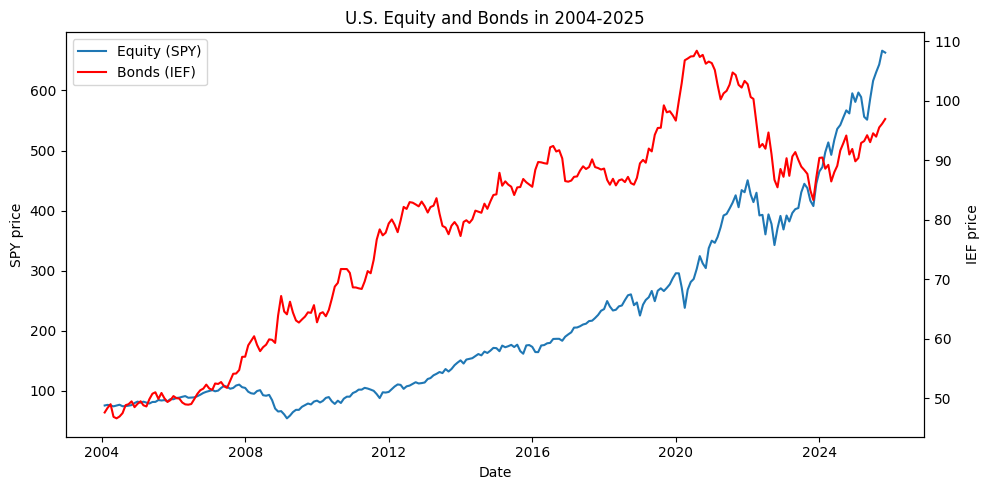

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df["px_spy"], label="Equity (SPY)")
ax.set_ylabel("SPY price")

ax2 = ax.twinx()
ax2.plot(df.index, df["px_ief"], label="Bonds (IEF)", color='red')
ax2.set_ylabel("IEF price")

ax.set_title("U.S. Equity and Bonds in 2004-2025")
ax.set_xlabel("Date")

lines = ax.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

As you can see, the period has been relatively good for both asset classes. A common way to combine these in a portfolio has been the "60/40 portfolio" (e.g., https://www.morganstanley.com/im/es-es/intermediary-investor/insights/articles/big-picture-return-of-the-60-40.html ). The underlying idea of such a combo is risk mitigation and, ultimately, better risk-adjusted performance.

Let's look at the performance of each asset class in the period, together with the 60/40 portfolio:

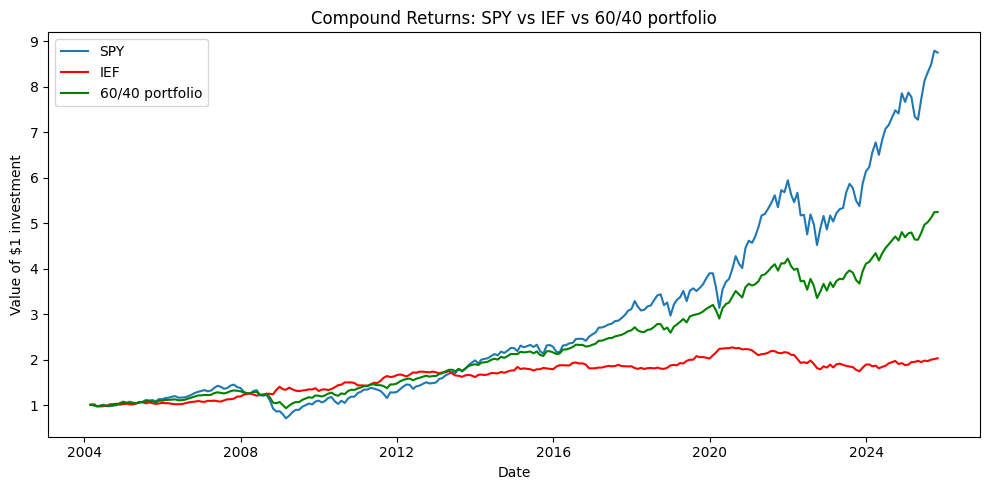

In [5]:
df["ret_6040"] = 0.6 * df["ret_spy"] + 0.4 * df["ret_ief"]

cum = (1 + df[["ret_spy", "ret_ief", "ret_6040"]]).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum.index, cum["ret_spy"], label="SPY")
plt.plot(cum.index, cum["ret_ief"], label="IEF", color='red')
plt.plot(cum.index, cum["ret_6040"], label="60/40 portfolio", color='green')

plt.title("Compound Returns: SPY vs IEF vs 60/40 portfolio")
plt.xlabel("Date")
plt.ylabel("Value of $1 investment")
plt.legend()
plt.tight_layout()
plt.show()

Clearly, the largest performance is achieved by investing in the stock market, but the 60/40 portfolio provides a very interesting (superior) risk-adjusted performance:

In [6]:
rets = df[["ret_spy", "ret_ief", "ret_6040"]].dropna()
n_months = rets.shape[0]
years = n_months / 12.0

# Perf Metrics
growth = (1 + rets).prod()
ann_return = growth**(1/years) - 1               # CAGR
ann_vol    = rets.std() * np.sqrt(12)            # annualized vol
sharpe     = ann_return / ann_vol                # rf = 0

perf = pd.DataFrame({
    "Annualized Return": ann_return,
    "Annualized Volatility": ann_vol,
    "Sharpe Ratio": sharpe
}).rename(index={"ret_spy": "SPY", "ret_ief": "IEF", "ret_6040": "60/40"})

out = perf.copy()
out["Annualized Return"] = out["Annualized Return"].map(lambda x: f"{x:.2%}")
out["Annualized Volatility"] = out["Annualized Volatility"].map(lambda x: f"{x:.2%}")
out["Sharpe Ratio"] = out["Sharpe Ratio"].map(lambda x: f"{x:.2f}")

print(out)

      Annualized Return Annualized Volatility Sharpe Ratio
SPY              10.49%                14.63%         0.72
IEF               3.32%                 6.54%         0.51
60/40             7.92%                 8.97%         0.88


Still, the ideal investment strategy would try to 'time' these 60 and 40 portfolio tilts to reflect times in which Equity or Bonds are going to perform better. To that end, we can leverage our RL knowledge and build an algorithm that expands portfolio rotation beyond the classic 60/40 allocations!

## **2. The RL setup**

The first step towards building a RL algorithm that beats the 60/40 allocation is to define the setup. This includes, as you know, **states**, **actions**, **rewards**, and **transition probabilities**. Differently from what we did in previous examples, we are going to let the data speak towards deciding each of these:

- **States**: We will classify states based on rolling past performance (momentum) and volatility of each of the assets:
    
    -  Equity momentum: {negative, positive} performance of U.S. Equity in the past 6 months.
    
    - Bond momentum:  {negative, positive} performance of U.S. Bonds in the past 6 months.

    - Volatility regime: {high, mid, low} 12-month rolling volatility for U.S. Equity and Bonds.

The combination of these cutoffs produces a total of 12 states, illustrated in the following table:


| State ID | eq_mom | bond_mom | vol_regime |
| -------: | :----: | :------: | :--------: |
|        1 |   neg  |    neg   |     low    |
|        2 |   neg  |    neg   |     mid    |
|        3 |   neg  |    neg   |    high    |
|        4 |   neg  |    pos   |     low    |
|        5 |   neg  |    pos   |     mid    |
|        6 |   neg  |    pos   |    high    |
|        7 |   pos  |    neg   |     low    |
|        8 |   pos  |    neg   |     mid    |
|        9 |   pos  |    neg   |    high    |
|       10 |   pos  |    pos   |     low    |
|       11 |   pos  |    pos   |     mid    |
|       12 |   pos  |    pos   |    high    |



- **Actions**: To expand the universe of actions from the 60/40 portfolio, we are going to let our agent choose among 5 different allocations:

| Action ID | Weights (Equity, Bonds) | Description |
| --------: | :---------------------: | :---------- |
|         1 |       (1.00, 0.00)      | 100% Equity |
|         2 |       (0.75, 0.25)      | 75/25       |
|         3 |       (0.50, 0.50)      | 50/50       |
|         4 |       (0.25, 0.75)      | 25/75       |
|         5 |       (0.00, 1.00)      | 100% Bonds  |

On top of that, we could also going to consider transaction costs, for example of 10 bps per dollar traded:

$$
Monthly \ transaction \ cost = turnover \times (cost \ per \ \$1 \ traded) = \frac{1}{2}\sum_i | w_i^t - w_i^{t-1}| \cdot 0.001
$$

In the case of 2 assets, this simplifies to:

$$
Monthly \ transaction \ cost = turnover \times (cost \ per \ \$1 \ traded) =  | w_E^t - w_E^{t-1}| \cdot 0.001
$$


These could be incorporated as part of the rewards, but for now let's leave them out and simply play around with them in the backtesting.


- **Rewards**: these are quite straightforward to define, as they are simply the next month's portfolio return:

$$
r_{t+1}(a) = w_E(a) Ret_{t+1}^{E} + w_B (a) Ret_{t+1}^B
$$

In order to estimate the rewards of a given state $s_t = s$, we simply average returns through all realizations of returns in that state for our training sample:

$$
\hat{R}(s, a) = mean(r_{t+1}(a) | s_t = s)
$$

- **Transition probabilities**: for simplicity, we will assume that the agent's allocations do not have an impact on transition probabilities. This is something quite realistic for "small players" in the market, but not so much for big fish. Hence, we could simply obtain an estimate for $P(s, s')$ from the data as:

$$
\hat{P}(s, s') = \frac{N(s → s')}{\sum_j N(s → j)}
$$

## **3. Implementing our RL algorithm**

Now that we have conceptually defined the setup of states, actions, rewards and transition probabilities, let's begin with the implementation.

Now, to successfully build an unbiased algorithm, it's important to make sure we are not "contaminating" agents' decisions with future data that will not be available at the time of the decision. For that, we are going to split our sample in  **train** and **test** periods. For now, its important we define our train sample, which will end in Decemeber 2016.


### 3.1. Coding the setup

In coding our setup, let's begin with the **states** we are going to consider:

In [7]:
# Rolling features
roll6_spy = (1 + df["ret_spy"]).rolling(6).apply(np.prod, raw=True) - 1
roll6_ief = (1 + df["ret_ief"]).rolling(6).apply(np.prod, raw=True) - 1
vol12_spy = df["ret_spy"].rolling(12).std() * np.sqrt(12)

df["eq_mom"]   = np.where(roll6_spy > 0, "pos", "neg")
df["bond_mom"] = np.where(roll6_ief > 0, "pos", "neg")
df["vol_raw"]  = vol12_spy

# Lag all three by 1 month to avoid look-ahead
df[["eq_mom","bond_mom","vol_raw"]] = df[["eq_mom","bond_mom","vol_raw"]].shift(1)

# Compute volatility tertiles on TRAIN (and apply same cutoffs to TEST sample to avoid leakage)
train_start, train_end = "2004-01-31", "2016-12-31"
train_mask = (df.index >= train_start) & (df.index <= train_end)


q1, q2 = df.loc[train_mask, "vol_raw"].quantile([1/3, 2/3])

def vol_bucket(v):
    if pd.isna(v): return np.nan
    if v <= q1:    return "low"
    if v <= q2:    return "mid"
    return "high"

df["vol_regime"] = df["vol_raw"].map(vol_bucket)

# Map to state_id in 1 to 12 id
eq_map, bond_map, vol_map = {"neg":0,"pos":1}, {"neg":0,"pos":1}, {"low":0,"mid":1,"high":2}
idx_eq   = df["eq_mom"].map(eq_map)
idx_bond = df["bond_mom"].map(bond_map)
idx_vol  = df["vol_regime"].map(vol_map)
df["state_id"] = (idx_eq*6 + idx_bond*3 + idx_vol + 1).astype("Int64")

print(df[["eq_mom","bond_mom","vol_regime","state_id"]].dropna().head(10))

           eq_mom bond_mom vol_regime  state_id
date                                           
2005-02-28    pos      pos        low        10
2005-03-31    pos      neg        low         7
2005-04-30    pos      neg        low         7
2005-05-31    pos      pos        low        10
2005-06-30    pos      pos        low        10
2005-07-31    neg      pos        low         4
2005-08-31    pos      pos        low        10
2005-09-30    pos      pos        low        10
2005-10-31    pos      pos        low        10
2005-11-30    pos      neg        low         7


In [8]:

# Train slice with fully-defined states
train = df.loc[train_mask].copy()
train = train.dropna(subset=["state_id", "ret_spy", "ret_ief"])

# Next-month (t+1) state and returns for rewards/transition estimates
train["state_next"] = train["state_id"].shift(-1)
train["ret_spy_fwd"] = train["ret_spy"].shift(-1)
train["ret_ief_fwd"] = train["ret_ief"].shift(-1)

# Keep rows where the forward info exists
train = train.dropna(subset=["state_next", "ret_spy_fwd", "ret_ief_fwd"])
train["state_next"] = train["state_next"].astype("Int64")

And these are the ocurrances of each state in the train sample (as you can see, there are some states that never happened in this sample):

In [9]:
state_counts = train["state_id"].value_counts().sort_index()
print(state_counts)

state_id
2      1
3      1
4      1
5     15
6     14
7     18
8      8
9     12
10    29
11    22
12    21
Name: count, dtype: Int64


Next, let's code **actions**:

In [10]:
ACTIONS = {1:(1.0,0.0), 2:(0.75,0.25), 3:(0.5,0.5), 4:(0.25,0.75), 5:(0.0,1.0)}

We can also estimate **transition probabilities** from the data, as described in the previous section:

In [11]:
# Counts of transitions
counts = pd.crosstab(train["state_id"], train["state_next"]).astype(float)

P = (counts).div((counts).sum(axis=1), axis=0)

print("P(s, s')", P)     # 12x12 (or smaller if some states never appear)

P(s, s') state_next     2         3         4         5         6         7         8   \
state_id                                                                        
2           0.000  0.000000  0.000000  1.000000  0.000000  0.000000  0.000000   
3           0.000  0.000000  0.000000  0.000000  1.000000  0.000000  0.000000   
4           0.000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
5           0.000  0.066667  0.000000  0.666667  0.066667  0.000000  0.000000   
6           0.000  0.000000  0.000000  0.071429  0.642857  0.000000  0.000000   
7           0.000  0.000000  0.000000  0.000000  0.000000  0.666667  0.055556   
8           0.125  0.000000  0.000000  0.000000  0.000000  0.125000  0.500000   
9           0.000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
10          0.000  0.000000  0.034483  0.034483  0.000000  0.137931  0.034483   
11          0.000  0.000000  0.000000  0.090909  0.045455  0.045455  0.090909   
12          0.000  

And **rewards** per state:

In [12]:
# Vectorized next-month portfolio return for each action
def r_next(we, wb):
    return we*train["ret_spy_fwd"] + wb*train["ret_ief_fwd"]

R_list = []
for a_id, (we, wb) in ACTIONS.items():
    # r_{t+1}(a) conditional on S_t = s
    r_next_a = r_next(we, wb)
    r_by_state = r_next_a.groupby(train["state_id"]).mean()
    R_list.append(r_by_state.rename(a_id))

# Combine to a DataFrame: rows = state (1..12), cols = action_id (1..5)
R = pd.concat(R_list, axis=1).sort_index()
R.columns.name = "action_id"

print("R(s,a) — expected next-month return per state:")
print(R.round(5))

R(s,a) — expected next-month return per state:
action_id        1        2        3        4        5
state_id                                              
2          0.08506  0.06220  0.03935  0.01649 -0.00637
3         -0.06961 -0.03282  0.00397  0.04075  0.07754
4         -0.00937 -0.00203  0.00532  0.01266  0.02000
5         -0.02040 -0.01427 -0.00814 -0.00202  0.00411
6          0.01581  0.01233  0.00884  0.00535  0.00186
7          0.00766  0.00751  0.00736  0.00721  0.00706
8         -0.00115  0.00014  0.00143  0.00271  0.00400
9          0.01535  0.01287  0.01040  0.00793  0.00545
10         0.01064  0.00876  0.00688  0.00500  0.00312
11        -0.00115 -0.00054  0.00007  0.00068  0.00129
12         0.02226  0.01758  0.01290  0.00822  0.00354


### 3.2. Policy evaluation

Once we have our setup ready, we can transition to the next step: **policy evaluation**. Let's define a function for that:

In [13]:
def policy_eval(P_df, R_df, policy, gamma=0.99, states=None,
                method="iter", tol=1e-8, max_iter=10_000):
    """
    Evaluate V^π for a fixed policy π in a tabular MDP.

    Inputs
    ------
    P_df : DataFrame   shape [S, S]   rows, cols = state ids (e.g., 1..12), rows sum to 1
    R_df : DataFrame   shape [S, A]   rows = state ids, cols = action ids (1..5)
    policy : dict      {state_id -> action_id}  e.g., {1:3, 2:3, ..., 12:3} for 50/50
    gamma : float      discount (monthly), e.g., 0.99
    states : list[int] explicit state order; default = sorted union of P/R/policy keys
    method : "iter" or "solve"
    tol : float        convergence tolerance for iterative method
    max_iter : int     safety cap on iterations

    Returns
    -------
    V : pd.Series      V^π over `states`
    """
    # --- State space
    if states is None:
        S = sorted(set(P_df.index).union(P_df.columns).union(R_df.index).union(policy.keys()))
    else:
        S = list(states)

    n = len(S); idx = {s:i for i,s in enumerate(S)}

    # --- Build P with 0's if a state is missing
    P = np.zeros((n, n))
    for s in S:
        if s in P_df.index:
            row = P_df.loc[s].reindex(S).fillna(0.0).values
            if row.sum() == 0:  # degenerate: make it a self-loop
                row[idx[s]] = 1.0
            P[idx[s], :] = row
        else:
            P[idx[s], idx[s]] = 1.0

    # --- R^π
    r_pi = np.zeros(n)
    for s in S:
        a = policy.get(s, None)
        r_pi[idx[s]] = float(R_df.loc[s, a]) if (a is not None and s in R_df.index) else 0.0

    # --- we can either solve linearly, or through iterations
    if method == "solve":
        V = np.linalg.solve(np.eye(n) - gamma * P, r_pi)
    else:
        V = np.zeros(n)
        for _ in range(max_iter):
            V_new = r_pi + gamma * P @ V
            if np.max(np.abs(V_new - V)) < tol:
                V = V_new
                break
            V = V_new

    return pd.Series(V, index=S, name="V_pi")

### 3.3. Policy improvement

As we already know, next step is **policy improvement**:

In [14]:
def Q_function(V, R_df, P_df, gamma=0.99):
    """
    Returns Qπ as a DataFrame [states x actions], given:
      V    : pd.Series indexed by state ids
      R_df : pd.DataFrame rows=states, cols=action ids (expected next-month returns)
      P_df : pd.DataFrame rows=states, cols=states (transition matrix; action-independent)
    Computes: Q(s,a) = R(s,a) + gamma * sum_{s'} P(s,s') * V(s')
    """

    states = R_df.index
    V = V.reindex(states).fillna(0.0)
    P = P_df.reindex(index=states, columns=states).fillna(0.0)

    Pv = P.values @ V.values
    Q = R_df.copy()
    for a in Q.columns:
        Q[a] = R_df[a].fillna(0.0).values + gamma * Pv
    return Q

def policy_improv(V, R_df, P_df, gamma=0.99, deterministic=True):
    """
    Greedy improvement: π'(s) = argmax_a Qπ(s,a)
    Returns:
      new_policy : list of action ids aligned to R_df.index order
      Q_df       : DataFrame of Q(s,a)
    """
    Q = Q_function(V, R_df, P_df, gamma=gamma)
    best_actions = Q.idxmax(axis=1)
    new_policy = best_actions.tolist()
    return new_policy, Q

### 3.4. Policy iteration

Finally, we can find the optimal policy per state (remember the Gridworld?) based on the train sample:

In [15]:
def policy_iteration(P_df, R_df, gamma=0.99, init_policy=None, max_iter=50, tol=1e-8):

    states = list(R_df.index)
    if init_policy is None:
        # Initialize from 50/50 (action 3) everywhere
        init_policy = {s: 3 for s in states}

    pi = init_policy.copy()
    for k in range(max_iter):
        V = policy_eval(P_df, R_df, pi, gamma=gamma, method="iter", tol=tol)
        pi_new, Q = policy_improv(V, R_df, P_df, gamma=gamma)
        pi_new = {s: a for s, a in zip(states, pi_new)}

        if all(pi_new[s] == pi[s] for s in states):
            return pi, V, Q   # Converged!
        pi = pi_new
    return pi, V, Q

In [16]:
PI_star, V_star, Q_star = policy_iteration(P, R, gamma=0.99)

Thus, the optimal policy based on this data would be such that:



In [17]:
ACTIONS_dict = {
    1: ((1.0,0.0), "100% Equity"),
    2: ((0.75,0.25), "75/25"),
    3: ((0.5,0.5), "50/50"),
    4: ((0.25,0.75), "25/75"),
    5: ((0.0,1.0), "100% Bonds"),
}

rows = []
for s, a in sorted(PI_star.items()):
    (we, wb), name = ACTIONS_dict[int(a)]
    rows.append((s, int(a), (we, wb), name))
pd.DataFrame(rows, columns=["State","Action ID","Weights (Eq,Bond)","Description"])


rows = []
for s, a in sorted(PI_star.items()):
    (we, wb), name = ACTIONS_dict[int(a)]
    rows.append((s, int(a), (we, wb), name))
pd.DataFrame(rows, columns=["State ID","Action ID","Weights (Eq,Bond)","Description"])

,State ID,Action ID,"Weights (Eq,Bond)",Description
0,2,1,"(1.0, 0.0)",100% Equity
1,3,5,"(0.0, 1.0)",100% Bonds
2,4,5,"(0.0, 1.0)",100% Bonds
3,5,5,"(0.0, 1.0)",100% Bonds
4,6,1,"(1.0, 0.0)",100% Equity
5,7,1,"(1.0, 0.0)",100% Equity
6,8,5,"(0.0, 1.0)",100% Bonds
7,9,1,"(1.0, 0.0)",100% Equity
8,10,1,"(1.0, 0.0)",100% Equity
9,11,5,"(0.0, 1.0)",100% Bonds


## **4. Backtest performance**

This optimal policy was obtained working through the train sample, aiming for no look-ahead bias. So, suppose we are an investor interested in following this policy at the begining of January 2017. How would have the strategy performed?

In [ ]:
# Define test period and actions
test = df.loc[df.index > "2016-12-31"].copy()
test["action"] = test["state_id"].map(lambda s: PI_star.get(int(s), np.nan)).astype("Int64")

# Weights from action
we = test["action"].map(lambda a: ACTIONS[int(a)][0] if pd.notna(a) else np.nan)
wb = 1 - we

# Next-month realized portfolio return (act at t, earn r at t+1)
r_e_next = test["ret_spy"].shift(-1)
r_b_next = test["ret_ief"].shift(-1)
test["r_gross"] = we * r_e_next + wb * r_b_next

# Transaction cost on switches (|Δ equity weight| × 10 bps)
turnover = (we - we.shift(1)).abs()
test["r_net"] = test["r_gross"] - 0.001 * turnover.fillna(0.0)

# Drop last row (no next-month r) and compute equity curve
bt_pi = test.dropna(subset=["r_net"]).copy()
bt_pi["curve"] = (1 + bt_pi["r_net"]).cumprod()


Let's compare this to the 60/40 portfolio:

In [19]:
r_6040 = 0.6 * test["ret_spy"].shift(-1) + 0.4 * test["ret_ief"].shift(-1)
bt_6040 = r_6040.dropna()
curve_6040 = (1 + bt_6040).cumprod()

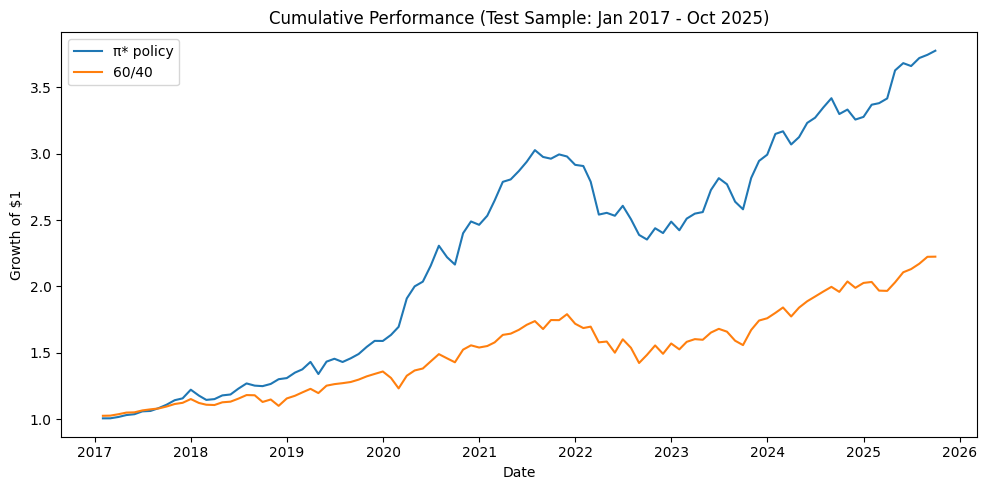

In [20]:
# Plot the two cumulative returns
curves = pd.DataFrame({
    "π* policy": bt_pi["curve"],
    "60/40": curve_6040
}).dropna()

plt.figure(figsize=(10, 5))
plt.plot(curves.index, curves["π* policy"], label="π* policy")
plt.plot(curves.index, curves["60/40"], label="60/40")

plt.title("Cumulative Performance (Test Sample: Jan 2017 - Oct 2025)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

Wow! It seems that our RL does a pretty good job in beating the famous 60/40 portfolio for the period considered, even after considering transaction costs. Is this the case also for risk-adjusted performance (namely Sharpe Ratios)?

In [21]:
r_pi   = bt_pi["r_net"]          # π* policy net monthly returns (test window)
r_6040 = bt_6040                 # 60/40 monthly returns (test window)

def perf_from_monthly(r: pd.Series):
    r = r.dropna()
    n = len(r); years = n / 12.0
    ann_ret = (1 + r).prod()**(1/years) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return ann_ret, ann_vol, sharpe

pi_ret,  pi_vol,  pi_sr  = perf_from_monthly(r_pi)
b_ret,   b_vol,   b_sr   = perf_from_monthly(r_6040)

perf = pd.DataFrame({
    "Annualized Return":   [pi_ret, b_ret],
    "Annualized Volatility":[pi_vol, b_vol],
    "Sharpe":       [pi_sr, b_sr],
}, index=["π* policy", "60/40"])

# Print
out = perf.copy()
out["Annualized Return"]    = out["Annualized Return"].map(lambda x: f"{x:.2%}")
out["Annualized Volatility"]= out["Annualized Volatility"].map(lambda x: f"{x:.2%}")
out["Sharpe"]        = out["Sharpe"].map(lambda x: f"{x:.2f}")
print(out)


          Annualized Return Annualized Volatility Sharpe
π* policy            16.39%                11.48%   1.43
60/40                 9.57%                10.31%   0.93


## **5. Conclusion**

Well done! In this lesson you have experienced first hand the power of reinforcement learing tools in asset management. RL can offer important enhancements of traditional asset allocation strategies, but it has to be used with caution.

In the next lesson, we will tackle another example of how RL can help inform the asset allocation context.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
